In [1]:
# Injected parameters
WDN_NAME = 'Alperovits'
BASE_DIR = '/home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/datasets/02e55f8fdffcd20ca84814956fc3195bdf3e45e70530748f420650f87108216c'
MODEL_DIR = '/home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/models/ad443c242debdedfc98621929db07566df6729c79c9626e95a6a1f19a2d07d78'
EPOCHS = 50
LR = 0.001
BATCH_SIZE = 32
HIDDEN_DIM = 64
NUM_LAYERS = 3
SEED = 42


# Graph Neural Network for Water Distribution Network

This notebook implements a Graph Neural Network (GNN) for predicting pressures in a water distribution network.

In [2]:
WDN_NAME = 'Alperovits'
BASE_DIR = '/home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/datasets/02e55f8fdffcd20ca84814956fc3195bdf3e45e70530748f420650f87108216c'


In [3]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, MessagePassing
from torch_geometric.data import Data, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import train_test_split


## Load the Dataset

Load the previously generated dataset from the saved files.

In [4]:
def load_dataset_splits(base_dir):
    """
    Load train/val/test datasets and stats from base_dir.
    """
    import os
    
    train_path = os.path.join(base_dir, "train_dataset.pt")
    val_path = os.path.join(base_dir, "val_dataset.pt")
    test_path = os.path.join(base_dir, "test_dataset.pt")
    stats_path = os.path.join(base_dir, "dataset_stats.json")
    metadata_path = os.path.join(base_dir, "dataset_metadata.json")
    
    train_data = torch.load(train_path, weights_only=False)
    val_data = torch.load(val_path, weights_only=False)
    test_data = torch.load(test_path, weights_only=False)
    
    with open(stats_path, 'r') as f:
        stats = json.load(f)
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    print(f"Train dataset loaded from: {train_path}")
    print(f"Validation dataset loaded from: {val_path}")
    print(f"Test dataset loaded from: {test_path}")
    print(f"Stats loaded from: {stats_path}")
    print(f"Metadata loaded from: {metadata_path}")
    
    return train_data, val_data, test_data, stats, metadata
    

import os
data_dir = os.path.join(BASE_DIR, "data_generator")
train_data, val_data, test_data, stats, metadata = load_dataset_splits(data_dir)
    
print(f"\nDataset Information:")
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Number of nodes: {train_data[0].x.shape[0]}")
print(f"Feature vector length: {train_data[0].x.shape[1]}")
print(f"Number of edges: {train_data[0].edge_index.shape[1]}")

Train dataset loaded from: /home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/datasets/02e55f8fdffcd20ca84814956fc3195bdf3e45e70530748f420650f87108216c/data_generator/train_dataset.pt
Validation dataset loaded from: /home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/datasets/02e55f8fdffcd20ca84814956fc3195bdf3e45e70530748f420650f87108216c/data_generator/val_dataset.pt
Test dataset loaded from: /home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/datasets/02e55f8fdffcd20ca84814956fc3195bdf3e45e70530748f420650f87108216c/data_generator/test_dataset.pt
Stats loaded from: /home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/datasets/02e55f8fdffcd20ca84814956fc3195bdf3e45e70530748f420650f87108216c/data_generator/dataset_stats.json
Metadata loaded from: /home/birkenma/Dokumente/INVERSE-PROBLEM/old/data/Alperovits/datasets/02e55f8fdffcd20ca84814956fc3195bdf3e45e70530748f420650f87108216c/data_generator/dataset_metadata.json

Dataset Information:
Training samp

## Prepare Data for Training

Convert the dataset into PyTorch Geometric Data objects and create train/validation/test splits.

In [5]:
# Create data loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print(f"\nData Split Information:")
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")


Data Split Information:
Training samples: 3200
Validation samples: 800
Test samples: 1000


/tmp/ipykernel_14852/1674142843.py:2: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
/tmp/ipykernel_14852/1674142843.py:3: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_data, batch_size=32)
/tmp/ipykernel_14852/1674142843.py:4: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_data, batch_size=32)


In [6]:
for batch in train_loader:
    print(batch.num_graphs)
    print(batch)
    print(batch.x)
    print(batch.y)
    print(batch.mask)
    break

32
DataBatch(x=[256, 3], edge_index=[2, 448], edge_attr=[448, 1], y=[256, 1], edge_type=[448, 1], mask=[256], d=[192], junction_names=[32], batch=[256], ptr=[33])
tensor([[1.2316, 1.1807, 0.0000],
        [0.6894, 1.1807, 0.0000],
        [0.9447, 1.1807, 0.0000],
        [1.2057, 1.1807, 0.0000],
        [0.4113, 0.4113, 0.0000],
        [0.6746, 1.1807, 0.0000],
        [1.3158, 1.1807, 2.0000],
        [1.2057, 1.1807, 3.0000],
        [1.2316, 1.0144, 0.0000],
        [0.6894, 1.0144, 0.0000],
        [0.9447, 1.0144, 0.0000],
        [1.2057, 1.0144, 0.0000],
        [0.4113, 0.4113, 0.0000],
        [0.6746, 1.0144, 0.0000],
        [1.3158, 1.0144, 2.0000],
        [1.2057, 1.0144, 3.0000],
        [1.2316, 1.0158, 0.0000],
        [0.6894, 1.0158, 0.0000],
        [0.9447, 1.0158, 0.0000],
        [1.2057, 1.0158, 0.0000],
        [0.4113, 0.4113, 0.0000],
        [0.6746, 1.0158, 0.0000],
        [1.3158, 1.0158, 2.0000],
        [1.2057, 1.0158, 3.0000],
        [1.2316, 0.92

In [7]:
data = train_data[0]
print(f"Training dataset size: {len(train_data)}")
print("---------------")
print(f"Number of nodes: {data.x.shape[0]}")
print("Graph:")
print("------")
print(f"Edges are directed: {data.is_directed()}")
print(f"Graph has isolated nodes: {data.has_isolated_nodes()}")
print(f"Graph has loops: {data.has_self_loops()}")
print(data.x[0])
#print(data.edge_index[0])
print(data.edge_attr[0])
print(data.y[0])
print(data.edge_type[0])

Training dataset size: 3200
---------------
Number of nodes: 8
Graph:
------
Edges are directed: True
Graph has isolated nodes: False
Graph has loops: False
tensor([1.2316, 1.1692, 0.0000])
tensor([0.7018])
tensor([1.2034])
tensor([0])


## Define the GNN Model

Implement the Graph Neural Network model architecture.

In [8]:
class GCN(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        # Define dimensions for GCN layers
        self.dim_hidden = dim_h * 4  # Hidden dimension for GCN layers
        
        # Add batch normalization
        self.batch_norm1 = torch.nn.BatchNorm1d(self.dim_hidden)
        self.batch_norm2 = torch.nn.BatchNorm1d(self.dim_hidden)
        self.batch_norm3 = torch.nn.BatchNorm1d(self.dim_hidden)
        
        # GCN layers with matching dimensions for residual connections
        self.gcn1 = GCNConv(dim_in, self.dim_hidden, improved=False, cached=False)
        self.gcn2 = GCNConv(self.dim_hidden, self.dim_hidden, improved=False, cached=False)
        self.gcn3 = GCNConv(self.dim_hidden, self.dim_hidden, improved=False, cached=False)
        
        # Final layers
        self.linear1 = torch.nn.Linear(self.dim_hidden, dim_h)
        self.linear2 = torch.nn.Linear(dim_h, dim_out)
        
        # Add dropout
        self.dropout = torch.nn.Dropout(p=0.2)

    def forward(self, x, edge_index, edge_attr=None):
        # First GCN layer
        h = self.gcn1(x, edge_index, edge_attr)
        h = self.batch_norm1(h)
        h = torch.relu(h)
        h = self.dropout(h)
        
        # Second GCN layer with residual
        h2 = self.gcn2(h, edge_index, edge_attr)
        h2 = self.batch_norm2(h2)
        h2 = torch.relu(h2)
        h2 = self.dropout(h2)
        h2 = h2 + h  # Residual connection
        
        # Third GCN layer with residual
        h3 = self.gcn3(h2, edge_index, edge_attr)
        h3 = self.batch_norm3(h3)
        h3 = torch.relu(h3)
        h3 = self.dropout(h3)
        h3 = h3 + h2  # Residual connection
        
        # Final layers
        h = self.linear1(h3)
        h = torch.relu(h)
        h = self.dropout(h)
        h = self.linear2(h)
        
        return h

def custom_loss(predictions, targets):
    """
    Combined loss function using MSE and Huber Loss.
    
    Args:
        predictions: Model predictions
        targets: Ground truth values
    
    Returns:
        Combined loss value
    """
    # MSE for overall accuracy
    mse_loss = F.mse_loss(predictions, targets)
    
    # Huber loss for robustness to outliers
    huber_loss = F.smooth_l1_loss(predictions, targets, beta=0.1)
    
    # Combine losses (adjust weights as needed)
    return 0.7 * mse_loss + 0.3 * huber_loss

def train(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data.x, data.edge_index, data.edge_attr)
        # Apply mask to predictions and targets
        masked_out = out[~data.mask]
        masked_targets = data.y[~data.mask]
        
        # Use custom loss
        loss = custom_loss(masked_out, masked_targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    
    return total_loss / len(train_loader.dataset)

def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.edge_attr)
            # Apply mask to predictions and targets
            masked_out = out[~data.mask]
            masked_targets = data.y[~data.mask]
            
            # Use custom loss
            loss = custom_loss(masked_out, masked_targets)
            total_loss += loss.item() * data.num_graphs
    
    return total_loss / len(loader.dataset)

# Training setup
def train_model(model, train_loader, val_loader, optimizer, scheduler, device, epochs, model_path):
    best_val_loss = float('inf')
    patience = 15
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        train_loss = train(model, train_loader, optimizer, device)
        
        # Validation
        val_loss = evaluate(model, val_loader, device)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Print progress
        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.5f}, Val Loss: {val_loss:.5f}')
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), model_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break
    
    return best_val_loss

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create model
model = GCN(dim_in=train_data[0].x.shape[1],
            dim_h=256,
            dim_out=1).to(device)

# Create optimizer with learning rate scheduler
optimizer = torch.optim.Adam(model.parameters(),
                           lr=0.001,
                           weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

import os
try:
    _model_dir = MODEL_DIR
except NameError:
    _model_dir = os.path.join(BASE_DIR, "gnn_model")
os.makedirs(_model_dir, exist_ok=True)
model_path = os.path.join(_model_dir, "best_model.pt")

# Train model
best_val_loss = train_model(model, train_loader, val_loader, 
                           optimizer, scheduler, device, epochs=100, model_path=model_path)

print(f'Best validation loss: {best_val_loss:.5f}')

Epoch 000, Train Loss: 0.29430, Val Loss: 0.00467


Epoch 001, Train Loss: 0.03266, Val Loss: 0.01064


Epoch 002, Train Loss: 0.02582, Val Loss: 0.00363


Epoch 003, Train Loss: 0.02339, Val Loss: 0.00157


Epoch 004, Train Loss: 0.02286, Val Loss: 0.00189


...

Epoch 095, Train Loss: 0.00531, Val Loss: 0.00023


Epoch 096, Train Loss: 0.00531, Val Loss: 0.00032


Epoch 097, Train Loss: 0.00523, Val Loss: 0.00022


Epoch 098, Train Loss: 0.00550, Val Loss: 0.00012


Epoch 099, Train Loss: 0.00557, Val Loss: 0.00017
Best validation loss: 0.00006


In [9]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 2372097


## Evaluate Model Performance

Evaluate the trained model on the test set and visualize predictions.


Test Set Metrics:
Combined Loss: 0.0001
MSE: 0.0000
MAE: 0.0041
RMSE: 0.0053
NMAE: 0.0038
MAPE: 0.0083
MaxPE: 0.4088
accuracy10: 0.9932
accuracy5: 0.9836


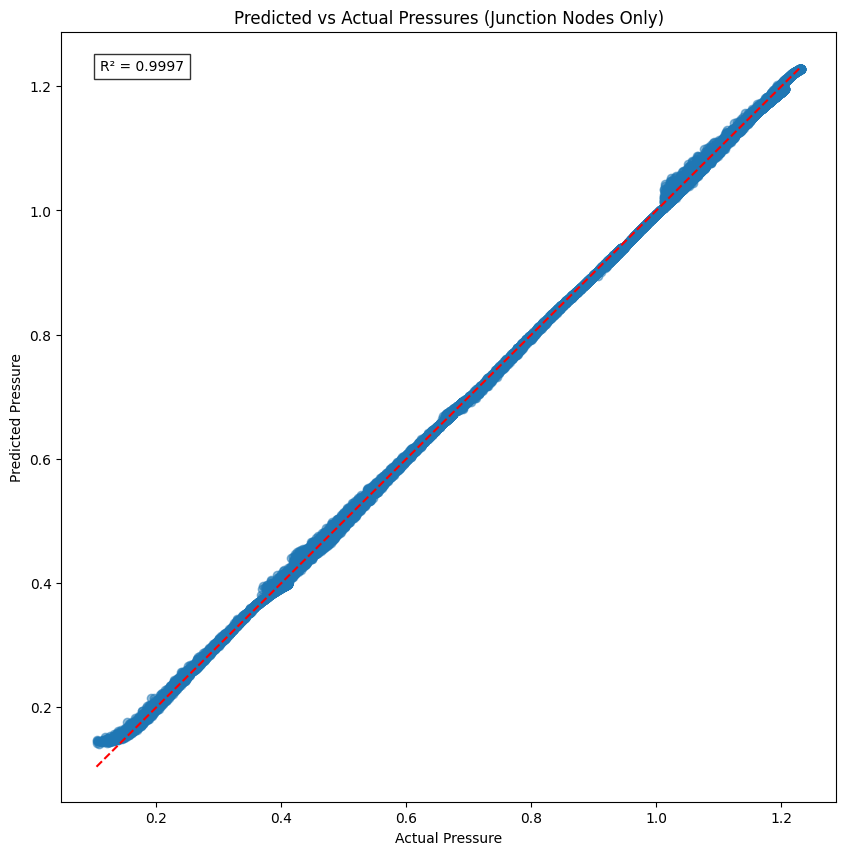


Pressure Range Statistics:
Actual Range: [0.10, 1.23]
Predicted Range: [0.14, 1.23]


In [10]:
def evaluate_predictions(model, loader, device, stats):
    model.eval()
    predictions = []
    actual = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.edge_attr)
            # Apply mask to predictions and targets
            masked_out = out[~data.mask]
            masked_targets = data.y[~data.mask]
            predictions.append(masked_out.cpu())
            actual.append(masked_targets.cpu())
    
    predictions = torch.cat(predictions, dim=0)
    actual = torch.cat(actual, dim=0)
    
    # Denormalize predictions and actual values
    #reservoir_head = stats['reservoir_head']
    #predictions = predictions * reservoir_head
    #actual = actual * reservoir_head
    
    # Calculate metrics using our custom loss
    combined_loss = custom_loss(predictions, actual).item()
    
    # Calculate individual metrics for detailed analysis
    mse = F.mse_loss(predictions, actual).item()
    mae = F.l1_loss(predictions, actual).item()
    rmse = torch.sqrt(torch.tensor(mse)).item()
    
    # Calculate relative error
    max_p = predictions.max()
    min_p = predictions.min()
    # relative_error = torch.mean(torch.abs((predictions - actual) / (actual + 1e-6))).item()
    NMAE = torch.mean(torch.abs((predictions - actual) / (max_p - min_p + 1e-6))).item()
    MAPE = torch.mean((torch.abs(predictions - actual) / torch.abs(actual + 1e-6))).item()
    MaxPE = torch.max((torch.abs(predictions - actual) / torch.abs(actual + 1e-6))).item()
    accuracy10 = torch.mean(((torch.abs(predictions - actual) / torch.abs(actual + 1e-6))<0.1).float()).item()
    accuracy5 = torch.mean(((torch.abs(predictions - actual) / torch.abs(actual + 1e-6))<0.05).float()).item()
    
    print(f"\nTest Set Metrics:")
    print(f"Combined Loss: {combined_loss:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"NMAE: {NMAE:.4f}")
    print(f"MAPE: {MAPE:.4f}")
    print(f"MaxPE: {MaxPE:.4f}")
    print(f"accuracy10: {accuracy10:.4f}")
    print(f"accuracy5: {accuracy5:.4f}")
    
    # Plot predictions vs actual
    plt.figure(figsize=(10, 10))
    plt.scatter(actual.numpy(), predictions.numpy(), alpha=0.5)
    plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--')
    plt.xlabel('Actual Pressure')
    plt.ylabel('Predicted Pressure')
    plt.title('Predicted vs Actual Pressures (Junction Nodes Only)')
    
    # Add R² score
    r2 = 1 - np.sum((predictions.numpy() - actual.numpy()) ** 2) / np.sum((actual.numpy() - np.mean(actual.numpy())) ** 2)
    plt.text(0.05, 0.95, f'R² = {r2:.4f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8))
    
    plt.show()
    
    # Print pressure range statistics
    print(f"\nPressure Range Statistics:")
    print(f"Actual Range: [{actual.min():.2f}, {actual.max():.2f}]")
    print(f"Predicted Range: [{predictions.min():.2f}, {predictions.max():.2f}]")
    
    return predictions, actual
# Load best model and evaluate
model.load_state_dict(torch.load(model_path))
predictions, actual = evaluate_predictions(model, train_loader, device, stats) # Use test_loader instead of train_loader


In [11]:
loader = test_data
with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = data.x[:,1].unsqueeze(1)
            print(out.shape)
            print(data.y.shape)
            break

torch.Size([8, 1])
torch.Size([8, 1])
